<a href="https://colab.research.google.com/github/raki-rankawat/stm32-thesis/blob/main/Model_Comparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [30]:
# =====================================================
# Imports
# =====================================================

import os
import time
import random
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from PIL import Image

import tarfile
from urllib.request import urlretrieve

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import DataLoader, Dataset
from torchvision import transforms

from google.colab import drive

In [31]:
# =====================================================
# Mount Google Drive
# =====================================================

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [32]:
# =====================================================
# Reproducibility + Device Setup
# =====================================================

SEED = 41

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [33]:
# =====================================================
# Fixed Manifest Paths
# =====================================================

MANIFEST_BASE_DIR = Path("/content/drive/My Drive/vww_fixed_split_manifests")

def manifest_paths():
    return {
        "train_person": MANIFEST_BASE_DIR / "train_person.txt",
        "val_person": MANIFEST_BASE_DIR / "val_person.txt",
        "train_non_person": MANIFEST_BASE_DIR / "train_non_person.txt",
        "val_non_person": MANIFEST_BASE_DIR / "val_non_person.txt",
    }

paths = manifest_paths()

for name, path in paths.items():
    if not path.exists():
        raise FileNotFoundError(f"❌ Missing manifest: {name} -> {path}")

In [34]:
# =====================================================
# Manifest Helpers
# =====================================================

def load_manifest(manifest_path):
    with open(manifest_path, "r") as f:
        return [Path(line.strip()) for line in f if line.strip()]

In [35]:
# =====================================================
# Custom Dataset from Manifest
# =====================================================

class VWWManifestDataset(Dataset):
    def __init__(self, person_manifest, nonperson_manifest, transform=None):
        self.transform = transform
        self.samples = []

        person_files = load_manifest(person_manifest)
        nonperson_files = load_manifest(nonperson_manifest)

        # Fixed class mapping
        # non_person -> 0
        # person     -> 1
        for p in nonperson_files:
            self.samples.append((p, 0))

        for p in person_files:
            self.samples.append((p, 1))

        self.class_to_idx = {"non_person": 0, "person": 1}
        self.classes = ["non_person", "person"]

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]

        image = Image.open(img_path).convert("RGB")

        if self.transform is not None:
            image = self.transform(image)

        return image, label

In [29]:
# =====================================================
# Dataset Restore (needed because manifests point to /content paths)
# =====================================================

VWW_URL = "https://www.silabs.com/public/files/github/machine_learning/benchmarks/datasets/vw_coco2014_96.tar.gz"

BASE_DIR = Path("/content/vww_work")
ARCHIVE_PATH = BASE_DIR / "vw_coco2014_96.tar.gz"
EXTRACT_DIR = BASE_DIR / "extracted"

def download_vww():
    BASE_DIR.mkdir(parents=True, exist_ok=True)

    if ARCHIVE_PATH.exists() and ARCHIVE_PATH.stat().st_size > 0:
        print("✅ VWW archive already downloaded")
        return

    print("⬇️ Downloading VWW archive...")
    urlretrieve(VWW_URL, ARCHIVE_PATH)
    print("✅ Download complete:", ARCHIVE_PATH)

def extract_vww():
    EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

    if any(EXTRACT_DIR.iterdir()):
        print("✅ VWW already extracted")
        return

    print("📦 Extracting VWW archive...")
    with tarfile.open(ARCHIVE_PATH, "r:gz") as tar:
        tar.extractall(EXTRACT_DIR)
    print("✅ Extraction complete:", EXTRACT_DIR)

def find_vww_root():
    for p in EXTRACT_DIR.rglob("person"):
        if p.is_dir() and (p.parent / "non_person").is_dir():
            return p.parent

    raise RuntimeError("❌ Could not find dataset directories")

download_vww()
extract_vww()
vww_root = find_vww_root()
print("✅ Found VWW root:", vww_root)

⬇️ Downloading VWW archive...
✅ Download complete: /content/vww_work/vw_coco2014_96.tar.gz
📦 Extracting VWW archive...


/tmp/ipykernel_4477/4045574897.py:31: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(EXTRACT_DIR)


✅ Extraction complete: /content/vww_work/extracted
✅ Found VWW root: /content/vww_work/extracted/vw_coco2014_96


In [36]:
# =====================================================
# Data Loader
# =====================================================

BATCH_SIZE = 64
IMG_SIZE = 96

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        (0.485, 0.456, 0.406),
        (0.229, 0.224, 0.225)
    )
])

val_data = VWWManifestDataset(
    person_manifest=paths["val_person"],
    nonperson_manifest=paths["val_non_person"],
    transform=eval_transform
)

val_loader = DataLoader(
    val_data,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Class mapping:", val_data.class_to_idx)
print("Validation size:", len(val_data))

Class mapping: {'non_person': 0, 'person': 1}
Validation size: 2000


In [37]:
# =====================================================
# MobileNetV2 Components
# =====================================================

class InvertedResidual(nn.Module):
    def __init__(self, in_channels, out_channels, stride, expand_ratio):
        super().__init__()

        hidden_dim = in_channels * expand_ratio
        self.use_residual = stride == 1 and in_channels == out_channels

        self.block = nn.Sequential(
            nn.Conv2d(in_channels, hidden_dim, 1, bias=False),
            nn.BatchNorm2d(hidden_dim),
            nn.ReLU6(inplace=True),

            nn.Conv2d(
                hidden_dim,
                hidden_dim,
                3,
                stride=stride,
                padding=1,
                groups=hidden_dim,
                bias=False
            ),
            nn.BatchNorm2d(hidden_dim),
            nn.ReLU6(inplace=True),

            nn.Conv2d(hidden_dim, out_channels, 1, bias=False),
            nn.BatchNorm2d(out_channels),
        )

    def forward(self, x):
        if self.use_residual:
            return x + self.block(x)
        return self.block(x)

In [38]:
# =====================================================
# MobileNetV2 Model
# =====================================================

class VWW_MobileNetV2(nn.Module):
    def __init__(self):
        super().__init__()

        self.initial = nn.Sequential(
            nn.Conv2d(3, 32, 3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU6(inplace=True)
        )

        self.features = nn.Sequential(
            InvertedResidual(32, 16, 1, 1),

            InvertedResidual(16, 24, 2, 6),
            InvertedResidual(24, 24, 1, 6),

            InvertedResidual(24, 32, 2, 6),
            InvertedResidual(32, 32, 1, 6),

            InvertedResidual(32, 64, 2, 6),
            InvertedResidual(64, 64, 1, 6),
        )

        self.final_conv = nn.Sequential(
            nn.Conv2d(64, 512, 1, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU6(inplace=True)
        )

        self.avgpool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Linear(512, 2)
        self._initialize_weights()

    def forward(self, x):
        x = self.initial(x)
        x = self.features(x)
        x = self.final_conv(x)
        x = self.avgpool(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01)
                nn.init.zeros_(m.bias)

In [39]:
# =====================================================
# VGG-Style CNN
# =====================================================

class VWW_VGGStyle(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            # Block 1 : 96 -> 48
            nn.Conv2d(3, 32, 3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),

            nn.Conv2d(32, 32, 3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),

            nn.MaxPool2d(2),

            # Block 2 : 48 -> 24
            nn.Conv2d(32, 64, 3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            nn.Conv2d(64, 64, 3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            nn.MaxPool2d(2),

            # Block 3 : 24 -> 12
            nn.Conv2d(64, 128, 3, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),

            nn.Conv2d(128, 128, 3, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),

            nn.MaxPool2d(2),

            # Block 4 : 12 -> 6
            nn.Conv2d(128, 256, 3, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),

            nn.Conv2d(256, 256, 3, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),

            nn.MaxPool2d(2),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 6 * 6, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),

            nn.Linear(512, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),

            nn.Linear(128, 2)
        )

        self._initialize_weights()

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01)
                nn.init.zeros_(m.bias)

In [40]:
# =====================================================
# Load Models
# =====================================================

# Use your FINAL baseline checkpoint here
MOBILENET_PATH = "/content/drive/My Drive/Colab Notebooks/mobilenetv2_seed_85.pth"
VGG_PATH = "/content/drive/My Drive/Colab Notebooks/vww_vggstyle_model.pth"

mobilenet = VWW_MobileNetV2().to(device)
mobilenet.load_state_dict(torch.load(MOBILENET_PATH, map_location=device))

vgg_model = VWW_VGGStyle().to(device)
vgg_model.load_state_dict(torch.load(VGG_PATH, map_location=device))

print("✅ Models loaded successfully")

✅ Models loaded successfully


In [41]:
# =====================================================
# Parameter Count
# =====================================================

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print("MobileNet Params:", count_parameters(mobilenet))
print("VGG Params:", count_parameters(vgg_model))

MobileNet Params: 151874
VGG Params: 5958242


In [42]:
# =====================================================
# Inference Latency
# =====================================================

def measure_latency(model, input_size=(1, 3, 96, 96), warmup=20, runs=100):
    model.eval()
    dummy = torch.randn(input_size).to(device)

    with torch.no_grad():
        for _ in range(warmup):
            _ = model(dummy)

        if device.type == "cuda":
            torch.cuda.synchronize()

        start = time.time()

        for _ in range(runs):
            _ = model(dummy)

        if device.type == "cuda":
            torch.cuda.synchronize()

        end = time.time()

    return (end - start) / runs

mobilenet_latency = measure_latency(mobilenet)
vgg_latency = measure_latency(vgg_model)

print("MobileNet Latency (seconds):", mobilenet_latency)
print("VGG Latency (seconds):", vgg_latency)

MobileNet Latency (seconds): 0.0022256660461425783
VGG Latency (seconds): 0.001165006160736084


In [43]:
# =====================================================
# Model Size
# =====================================================

mobilenet_temp_path = "mobilenet_temp.pth"
vgg_temp_path = "vgg_temp.pth"

torch.save(mobilenet.state_dict(), mobilenet_temp_path)
torch.save(vgg_model.state_dict(), vgg_temp_path)

print("MobileNet Size (MB):", os.path.getsize(mobilenet_temp_path) / 1e6)
print("VGG Size (MB):", os.path.getsize(vgg_temp_path) / 1e6)

MobileNet Size (MB): 0.681317
VGG Size (MB): 23.859197


In [44]:
# =====================================================
# Accuracy Evaluation
# =====================================================

def evaluate(model, loader, device):
    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():
        for X, y in loader:
            X = X.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)

            outputs = model(X)
            preds = torch.argmax(outputs, dim=1)

            correct += (preds == y).sum().item()
            total += y.size(0)

    return correct / total

mobilenet_acc = evaluate(mobilenet, val_loader, device)
vgg_acc = evaluate(vgg_model, val_loader, device)

print("MobileNet Validation Accuracy:", mobilenet_acc * 100)
print("VGG Validation Accuracy:", vgg_acc * 100)

MobileNet Validation Accuracy: 79.95
VGG Validation Accuracy: 83.3


In [45]:
# =====================================================
# Final Comparison Summary
# =====================================================

print("\n========== Final Comparison ==========")
print(f"MobileNet Validation Accuracy : {mobilenet_acc * 100:.2f}%")
print(f"VGG Validation Accuracy       : {vgg_acc * 100:.2f}%")
print(f"MobileNet Params              : {count_parameters(mobilenet):,}")
print(f"VGG Params                    : {count_parameters(vgg_model):,}")
print(f"MobileNet Latency             : {mobilenet_latency:.6f} sec")
print(f"VGG Latency                   : {vgg_latency:.6f} sec")
print(f"MobileNet Size                : {os.path.getsize(mobilenet_temp_path) / 1e6:.3f} MB")
print(f"VGG Size                      : {os.path.getsize(vgg_temp_path) / 1e6:.3f} MB")


========== Final Comparison ==========
MobileNet Validation Accuracy : 79.95%
VGG Validation Accuracy       : 83.30%
MobileNet Params              : 151,874
VGG Params                    : 5,958,242
MobileNet Latency             : 0.002226 sec
VGG Latency                   : 0.001165 sec
MobileNet Size                : 0.681 MB
VGG Size                      : 23.859 MB


### Predictions

In [46]:
# =====================================================
# Denormalize Images
# =====================================================

def denormalize(img):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return img * std + mean

In [52]:
# =====================================================
# Show Specific Validation Images (One Row)
# =====================================================

def show_specific_images(indices, dataset=val_data, model=mobilenet):
    model.eval()
    num_images = len(indices)

    plt.figure(figsize=(3 * num_images, 3))

    for i, idx in enumerate(indices):
        image, label = dataset[idx]

        input_tensor = image.unsqueeze(0).to(device)

        with torch.no_grad():
            output = model(input_tensor)
            probabilities = F.softmax(output, dim=1)
            confidence, predicted = torch.max(probabilities, 1)

        image_display = denormalize(image).clamp(0, 1)

        plt.subplot(1, num_images, i + 1)
        plt.imshow(image_display.permute(1, 2, 0).cpu())

        correct = predicted.item() == label
        color = "green" if correct else "red"

        plt.title(
            f"P: {val_data.classes[predicted.item()]}\n"
            f"T: {val_data.classes[label]}\n"
            f"{confidence.item() * 100:.1f}%",
            color=color
        )
        plt.axis("off")

    plt.tight_layout()
    plt.show()

In [53]:
# =====================================================
# Show Random Validation Predictions (One Row)
# =====================================================

def show_random_predictions(num_images=5, dataset=val_data, model=mobilenet):
    model.eval()

    indices = random.sample(range(len(dataset)), num_images)

    plt.figure(figsize=(3 * num_images, 3))

    for i, idx in enumerate(indices):
        image, label = dataset[idx]

        input_tensor = image.unsqueeze(0).to(device)

        with torch.no_grad():
            output = model(input_tensor)
            probabilities = F.softmax(output, dim=1)
            confidence, predicted = torch.max(probabilities, 1)

        image_display = denormalize(image).clamp(0, 1)

        plt.subplot(1, num_images, i + 1)
        plt.imshow(image_display.permute(1, 2, 0).cpu())

        correct = predicted.item() == label
        color = "green" if correct else "red"

        plt.title(
            f"P: {val_data.classes[predicted.item()]}\n"
            f"T: {val_data.classes[label]}\n"
            f"{confidence.item() * 100:.1f}%",
            color=color
        )
        plt.axis("off")

    plt.tight_layout()
    plt.show()

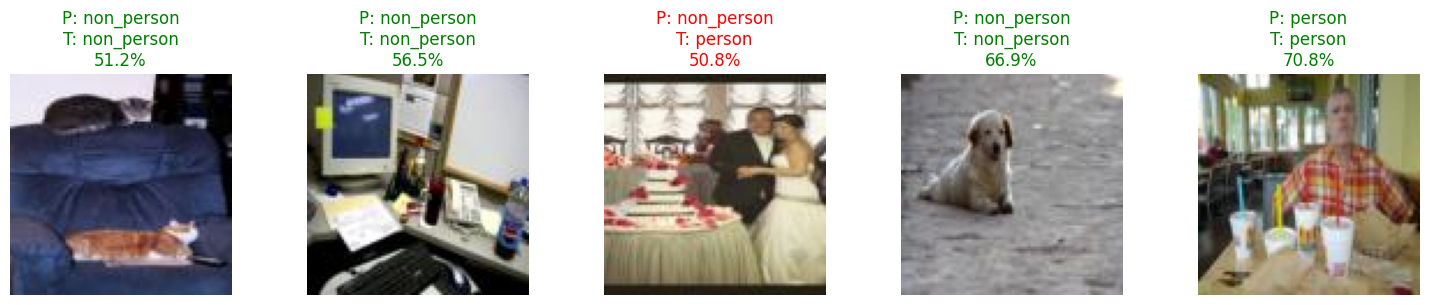

In [55]:
show_specific_images([500, 303, 1011, 999, 1001], model=mobilenet)

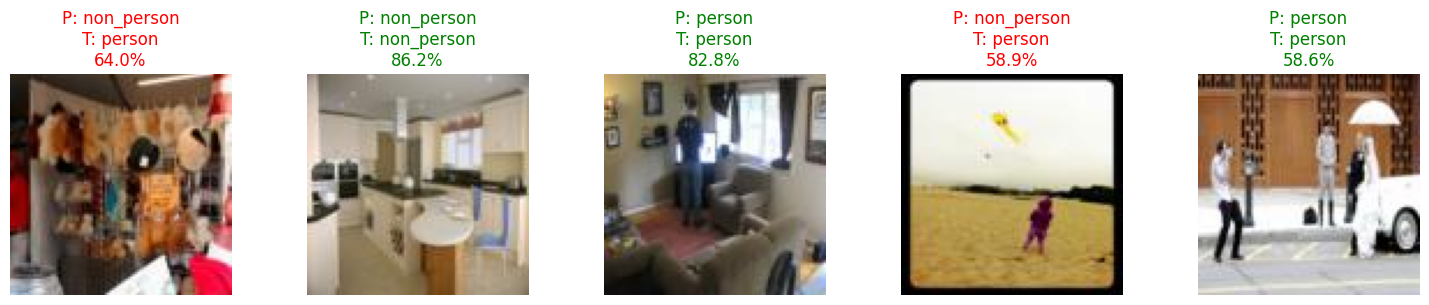

In [56]:
show_random_predictions(5, model=mobilenet)